# Google Play Store Analysis
## Data Science Project

**Objective:** Analyze Google Play Store apps data to understand app characteristics, user sentiments, and market trends.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

In [2]:
# Load datasets
df_store = pd.read_csv('googleplaystore.csv')
df_reviews = pd.read_csv('googleplaystore_user_reviews.csv')

print(f"Store Dataset Shape: {df_store.shape}")
print(f"Reviews Dataset Shape: {df_reviews.shape}")

Store Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Store dataset overview
print("=" * 50)
print("GOOGLE PLAY STORE DATASET")
print("=" * 50)
print("\nFirst 5 rows:")
display(df_store.head())
print("\nDataset Info:")
df_store.info()
print("\nMissing Values:")
print(df_store.isnull().sum())
print("\nBasic Statistics:")
display(df_store.describe())

GOOGLE PLAY STORE DATASET

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs        

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [4]:
# Reviews dataset overview
print("=" * 50)
print("USER REVIEWS DATASET")
print("=" * 50)
print("\nFirst 5 rows:")
display(df_reviews.head())
print("\nDataset Info:")
df_reviews.info()
print("\nMissing Values:")
print(df_reviews.isnull().sum())

USER REVIEWS DATASET

First 5 rows:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB

Missing Values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


## 4. Data Cleaning

In [5]:
# Clean Store Dataset
print("Cleaning Store Dataset...")

# Handle Rating
df_store['Rating'] = df_store['Rating'].fillna(df_store['Rating'].median())

# Parse Size
def parse_size(x):
    s = str(x).strip()
    if s.lower() in ['nan', 'none', ''] or 'Varies with device' in s:
        return np.nan
    s = s.replace(',', '').replace(' ', '')
    try:
        if s.endswith(('M', 'm')):
            return float(s[:-1])
        if s.endswith(('K', 'k')):
            return float(s[:-1]) / 1024
        return float(s) / (1024 * 1024)
    except:
        return np.nan

df_store['Size_MB'] = df_store['Size'].apply(parse_size)

# Clean Installs
df_store['Installs'] = df_store['Installs'].astype(str).str.replace(r'[+,]', '', regex=True)
df_store['Installs'] = pd.to_numeric(df_store['Installs'], errors='coerce').fillna(0).astype(int)

# Clean Price
df_store['Price'] = df_store['Price'].astype(str).str.replace(r'[^0-9\.]', '', regex=True)
df_store['Price'] = pd.to_numeric(df_store['Price'], errors='coerce').fillna(0.0)

# Convert Reviews to numeric
df_store['Reviews'] = pd.to_numeric(df_store['Reviews'], errors='coerce').fillna(0).astype(int)

# Parse Last Updated
df_store['Last Updated'] = pd.to_datetime(df_store['Last Updated'], errors='coerce')

# Remove invalid rows
df_store = df_store[df_store['Category'] != '1.9'].copy()

print(f"Store Dataset after cleaning: {df_store.shape}")

Cleaning Store Dataset...
Store Dataset after cleaning: (10840, 14)


In [6]:
# Clean Reviews Dataset
print("Cleaning Reviews Dataset...")

# Remove rows with missing sentiment data
df_reviews_clean = df_reviews.dropna(subset=['Sentiment']).copy()

print(f"Reviews Dataset after cleaning: {df_reviews_clean.shape}")

Cleaning Reviews Dataset...
Reviews Dataset after cleaning: (37432, 5)


## 5. Data Visualization

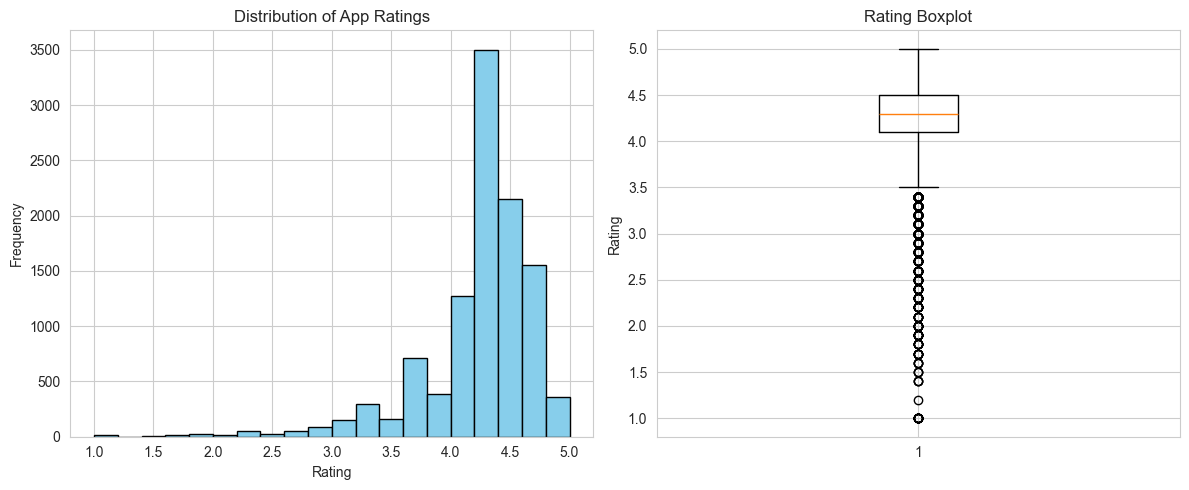

In [7]:
# Rating Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_store['Rating'], bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of App Ratings')

plt.subplot(1, 2, 2)
plt.boxplot(df_store['Rating'])
plt.ylabel('Rating')
plt.title('Rating Boxplot')
plt.tight_layout()
plt.show()

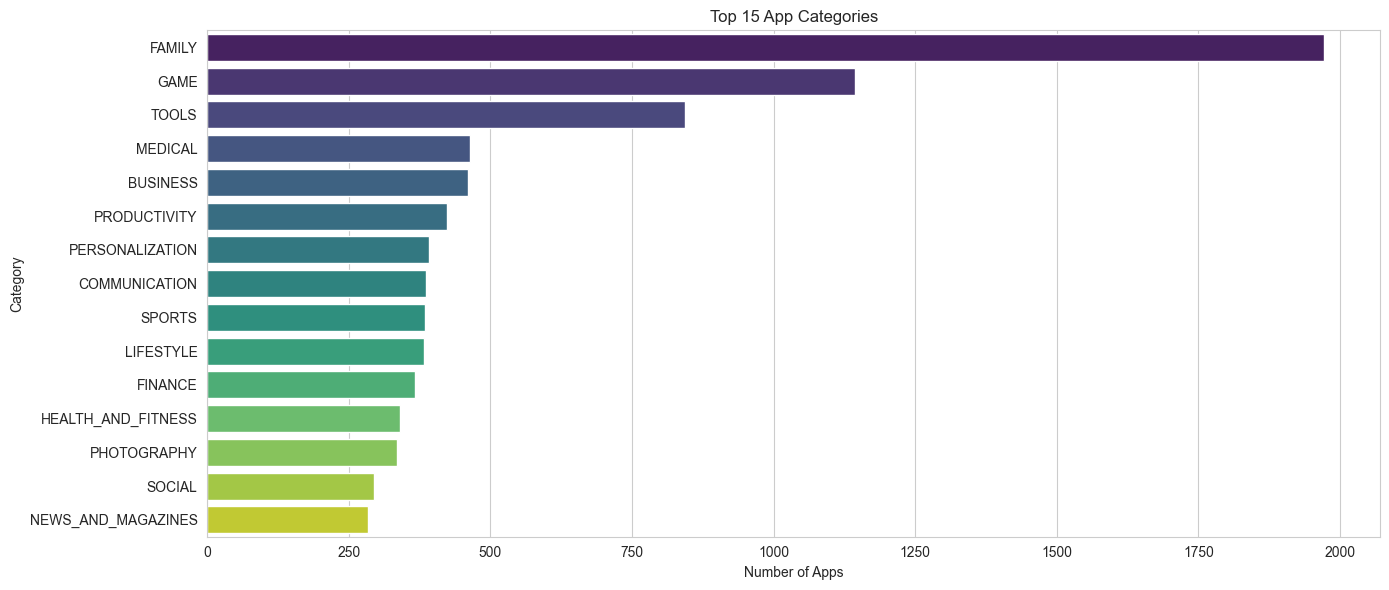

In [8]:
# Top Categories
plt.figure(figsize=(14, 6))
top_categories = df_store['Category'].value_counts().head(15)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.title('Top 15 App Categories')
plt.tight_layout()
plt.show()

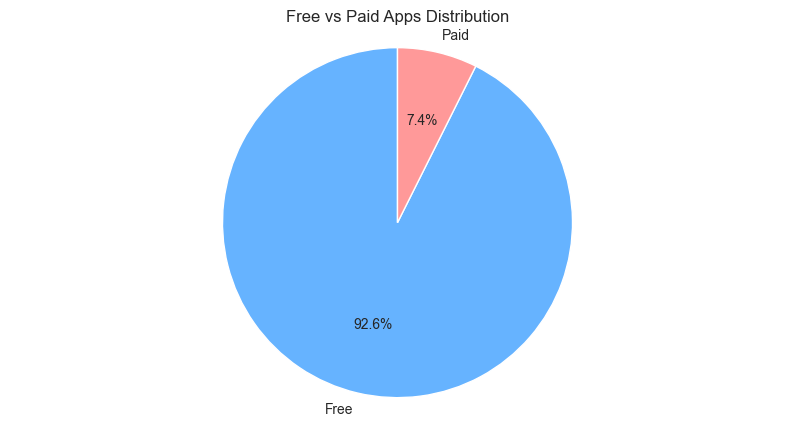

In [9]:
# Free vs Paid Apps
plt.figure(figsize=(10, 5))
type_counts = df_store['Type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Free vs Paid Apps Distribution')
plt.axis('equal')
plt.show()

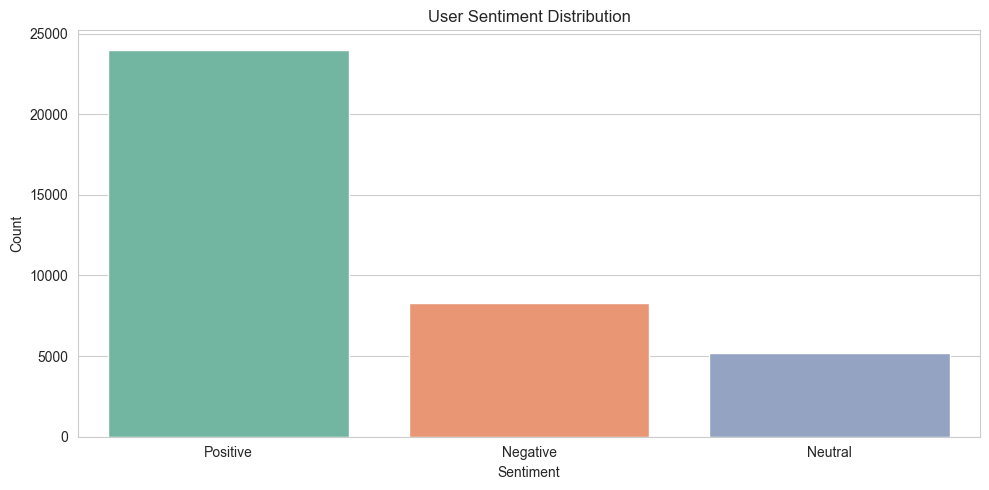

In [10]:
# Sentiment Distribution
plt.figure(figsize=(10, 5))
sentiment_counts = df_reviews_clean['Sentiment'].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('User Sentiment Distribution')
plt.tight_layout()
plt.show()

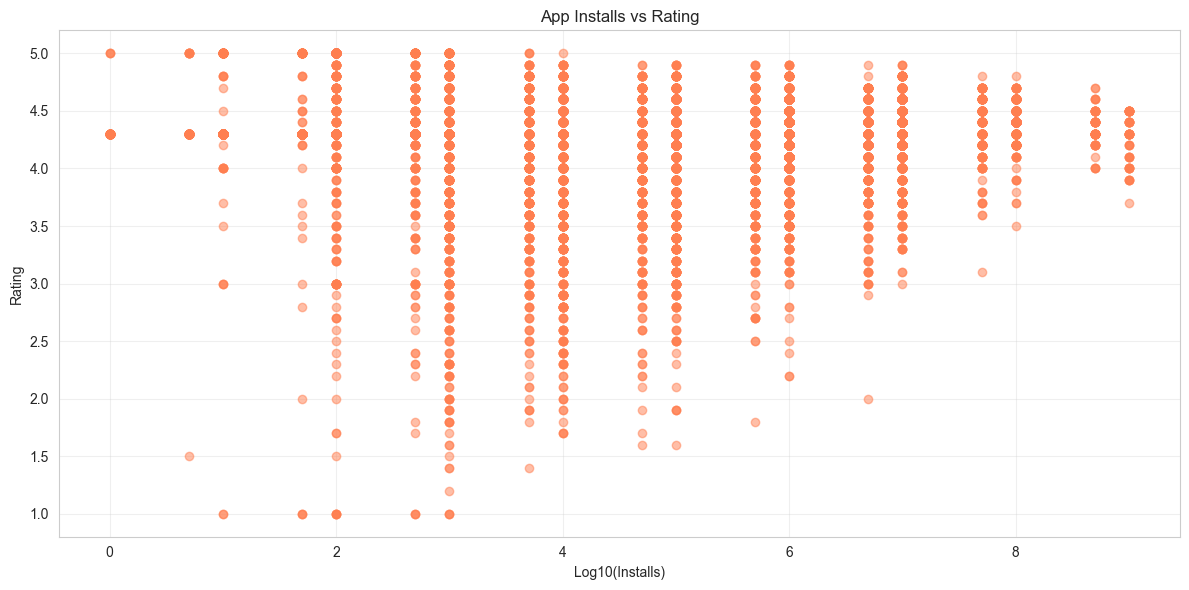

In [11]:
# Installs vs Rating
plt.figure(figsize=(12, 6))
df_plot = df_store[df_store['Installs'] > 0].copy()
plt.scatter(np.log10(df_plot['Installs']), df_plot['Rating'], alpha=0.5, c='coral')
plt.xlabel('Log10(Installs)')
plt.ylabel('Rating')
plt.title('App Installs vs Rating')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Statistical Analysis

In [12]:
# Category-wise statistics
category_stats = df_store.groupby('Category').agg({
    'Rating': 'mean',
    'Reviews': 'mean',
    'Installs': 'mean',
    'Price': 'mean'
}).round(2).sort_values('Rating', ascending=False)

print("\nTop 10 Categories by Average Rating:")
display(category_stats.head(10))


Top 10 Categories by Average Rating:


,Rating,Reviews,Installs,Price
Category,,,,
EVENTS,4.40,2515.91,249580.64,1.72
EDUCATION,4.39,253819.14,5586230.77,0.12
ART_AND_DESIGN,4.36,26376.00,1912893.85,0.09
BOOKS_AND_REFERENCE,4.34,95060.90,8318050.11,0.52
PERSONALIZATION,4.33,227923.83,5932384.65,0.39
PARENTING,4.30,15972.18,525351.83,0.16
GAME,4.29,1385858.70,30669601.76,0.25
BEAUTY,4.28,7476.23,513151.89,0.00
HEALTH_AND_FITNESS,4.28,111125.35,4642441.38,0.20


In [13]:
# Content Rating Analysis
content_rating_stats = df_store.groupby('Content Rating').agg({
    'App': 'count',
    'Rating': 'mean',
    'Installs': 'mean'
}).round(2).sort_values('App', ascending=False)
content_rating_stats.columns = ['App Count', 'Avg Rating', 'Avg Installs']

print("\nContent Rating Analysis:")
display(content_rating_stats)


Content Rating Analysis:


,App Count,Avg Rating,Avg Installs
Content Rating,,,
Everyone,8714,4.20,13100374.07
Teen,1208,4.24,28738700.66
Mature 17+,499,4.14,11071124.61
Everyone 10+,414,4.26,31965898.06
Adults only 18+,3,4.30,666666.67
Unrated,2,4.20,25250.00


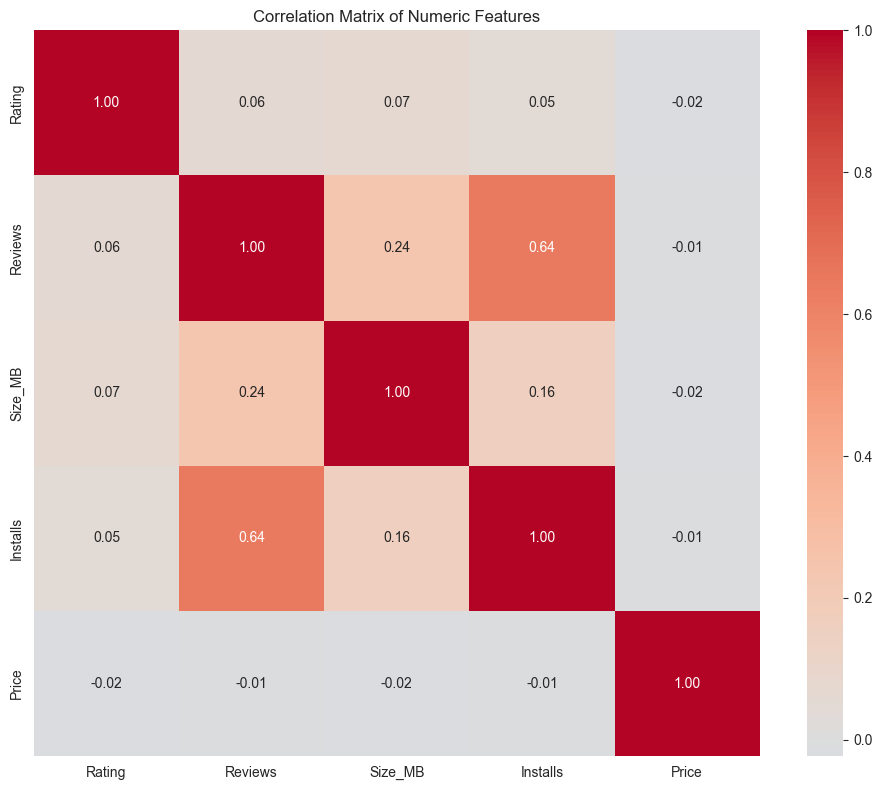

In [14]:
# Correlation Analysis
numeric_cols = ['Rating', 'Reviews', 'Size_MB', 'Installs', 'Price']
correlation_matrix = df_store[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

## 7. Advanced Analysis


Merged Dataset Shape: (72615, 18)


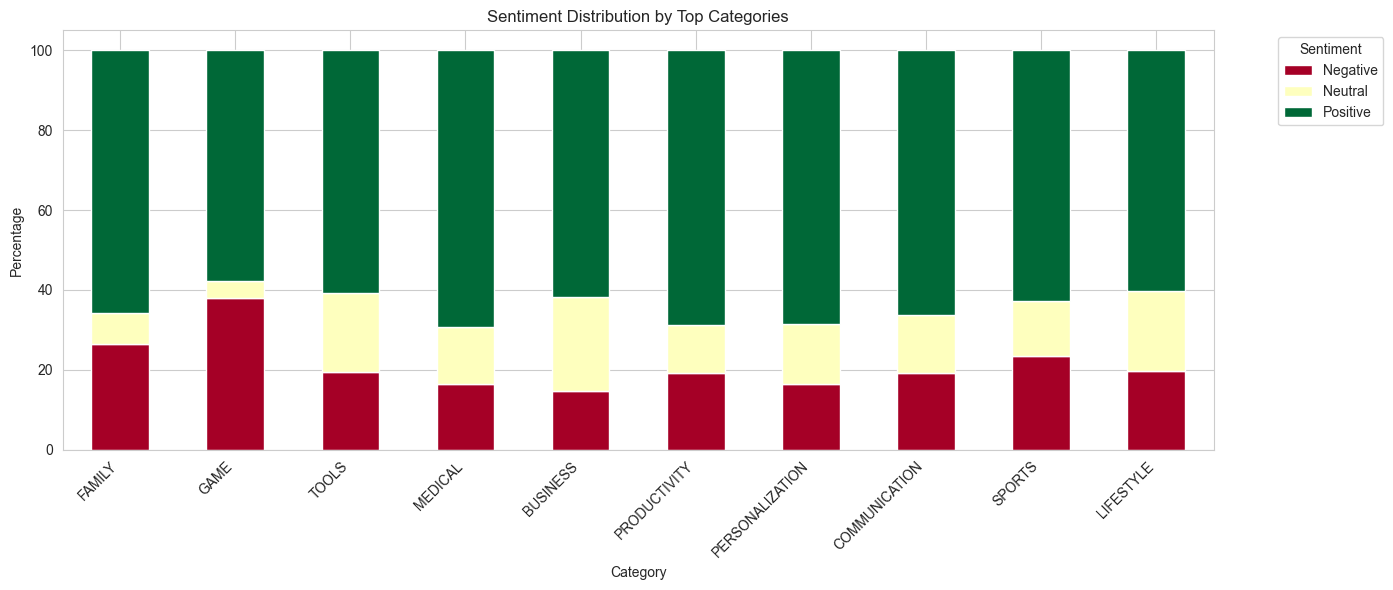

In [15]:
# Merge datasets for sentiment analysis
df_merged = pd.merge(df_store, df_reviews_clean, on='App', how='inner')
print(f"\nMerged Dataset Shape: {df_merged.shape}")

# Sentiment by Category
sentiment_by_category = pd.crosstab(df_merged['Category'], df_merged['Sentiment'], normalize='index') * 100
top_categories_sentiment = sentiment_by_category.loc[top_categories.head(10).index]

plt.figure(figsize=(14, 6))
top_categories_sentiment.plot(kind='bar', stacked=True, colormap='RdYlGn', ax=plt.gca())
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.title('Sentiment Distribution by Top Categories')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Top Rated Apps
top_rated = df_store[df_store['Reviews'] > 1000].nlargest(10, 'Rating')[['App', 'Category', 'Rating', 'Reviews', 'Installs']]
print("\nTop 10 Highly Rated Apps (with >1000 reviews):")
display(top_rated)


Top 10 Highly Rated Apps (with >1000 reviews):


,App,Category,Rating,Reviews,Installs
55,Tickets SDA 2018 and Exam from the State Traff...,AUTO_AND_VEHICLES,4.9,10479,100000
61,CDL Practice Test 2018 Edition,AUTO_AND_VEHICLES,4.9,7774,100000
64,DMV Permit Practice Test 2018 Edition,AUTO_AND_VEHICLES,4.9,6090,100000
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,197136,1000000
99,"ipsy: Makeup, Beauty, and Tips",BEAUTY,4.9,49790,1000000
177,eBoox new: Reader for fb2 epub zip books,BOOKS_AND_REFERENCE,4.9,2739,50000
712,"Learn Japanese, Korean, Chinese Offline & Free",EDUCATION,4.9,133136,1000000
1258,Lose Belly Fat in 30 Days - Flat Stomach,HEALTH_AND_FITNESS,4.9,38098,5000000
1260,Six Pack in 30 Days - Abs Workout,HEALTH_AND_FITNESS,4.9,272337,10000000
1307,StrongLifts 5x5 Workout Gym Log & Personal Tra...,HEALTH_AND_FITNESS,4.9,66791,1000000


In [17]:
# Most Installed Apps
most_installed = df_store.nlargest(10, 'Installs')[['App', 'Category', 'Rating', 'Installs', 'Type']]
print("\nTop 10 Most Installed Apps:")
display(most_installed)


Top 10 Most Installed Apps:


,App,Category,Rating,Installs,Type
152,Google Play Books,BOOKS_AND_REFERENCE,3.9,1000000000,Free
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,1000000000,Free
336,WhatsApp Messenger,COMMUNICATION,4.4,1000000000,Free
338,Google Chrome: Fast & Secure,COMMUNICATION,4.3,1000000000,Free
340,Gmail,COMMUNICATION,4.3,1000000000,Free
341,Hangouts,COMMUNICATION,4.0,1000000000,Free
381,WhatsApp Messenger,COMMUNICATION,4.4,1000000000,Free
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,1000000000,Free
386,Hangouts,COMMUNICATION,4.0,1000000000,Free
391,Skype - free IM & video calls,COMMUNICATION,4.1,1000000000,Free


## 8. Key Insights

In [18]:
# Generate key insights
print("=" * 60)
print("KEY INSIGHTS FROM GOOGLE PLAY STORE ANALYSIS")
print("=" * 60)

print(f"\n1. Dataset Overview:")
print(f"   - Total Apps: {len(df_store):,}")
print(f"   - Total Categories: {df_store['Category'].nunique()}")
print(f"   - Average Rating: {df_store['Rating'].mean():.2f}")

print(f"\n2. App Types:")
print(f"   - Free Apps: {(df_store['Type'] == 'Free').sum():,} ({(df_store['Type'] == 'Free').sum()/len(df_store)*100:.1f}%)")
print(f"   - Paid Apps: {(df_store['Type'] == 'Paid').sum():,} ({(df_store['Type'] == 'Paid').sum()/len(df_store)*100:.1f}%)")

print(f"\n3. Most Popular Category: {df_store['Category'].value_counts().index[0]}")
print(f"   - Number of Apps: {df_store['Category'].value_counts().values[0]:,}")

print(f"\n4. Sentiment Analysis:")
for sentiment in df_reviews_clean['Sentiment'].value_counts().index:
    count = df_reviews_clean['Sentiment'].value_counts()[sentiment]
    pct = count / len(df_reviews_clean) * 100
    print(f"   - {sentiment}: {count:,} ({pct:.1f}%)")

print(f"\n5. Price Analysis:")
paid_apps = df_store[df_store['Price'] > 0]
print(f"   - Average Paid App Price: ${paid_apps['Price'].mean():.2f}")
print(f"   - Maximum App Price: ${df_store['Price'].max():.2f}")

print(f"\n6. Size Analysis:")
print(f"   - Average App Size: {df_store['Size_MB'].mean():.2f} MB")
print(f"   - Median App Size: {df_store['Size_MB'].median():.2f} MB")

KEY INSIGHTS FROM GOOGLE PLAY STORE ANALYSIS

1. Dataset Overview:
   - Total Apps: 10,840
   - Total Categories: 33
   - Average Rating: 4.21

2. App Types:
   - Free Apps: 10,039 (92.6%)
   - Paid Apps: 800 (7.4%)

3. Most Popular Category: FAMILY
   - Number of Apps: 1,972

4. Sentiment Analysis:
   - Positive: 23,998 (64.1%)
   - Negative: 8,271 (22.1%)
   - Neutral: 5,163 (13.8%)

5. Price Analysis:
   - Average Paid App Price: $13.92
   - Maximum App Price: $400.00

6. Size Analysis:
   - Average App Size: 21.52 MB
   - Median App Size: 13.00 MB


## 9. Conclusions

Based on the analysis of Google Play Store data:

1. **Market Dominance**: Free apps dominate the Google Play Store, indicating a freemium business model preference.

2. **Quality Metrics**: Apps with higher ratings tend to have more reviews and installs, showing correlation between quality and popularity.

3. **Category Insights**: Certain categories have higher average ratings, suggesting better user satisfaction in specific niches.

4. **User Sentiment**: The sentiment analysis reveals overall user satisfaction patterns across different app categories.

5. **Pricing Strategy**: The pricing analysis shows market trends and optimal price points for paid applications.

### Recommendations:
- Focus on user experience to improve ratings
- Target popular categories with high engagement
- Consider freemium models for better market penetration
- Monitor user sentiment for continuous improvement